# Import libraries

In [1]:
import os
import pandas as pd
import utils_emotions as ue
import utils_llm_filtering as ulf

In [2]:
INPUT_PATH = "../data/v2/clean_posts_bsky.csv"
RESULTS_PATH = "../data/v2/"

# Emotion detection

In [ ]:
df = pd.read_csv(INPUT_PATH)

emotion_classifier = ue.load_emotion_classifier(
    model_name="j-hartmann/emotion-english-distilroberta-base",
    device=-1  # use 0 if you have GPU
)

emotions_df = ue.add_emotion_columns(
    df,
    classifier=emotion_classifier,
    text_column="Clean_Comment",
    min_confidence=0.0,
    batch_size=32,
    progress_every=1000
)

display(ue.summarize_emotions(emotions_df))

os.makedirs(RESULTS_PATH, exist_ok=True)
emotions_df.to_csv(
    os.path.join(RESULTS_PATH, "bsky_with_emotions.csv"),
    index=False
)

Loading emotion classifier: j-hartmann/emotion-english-distilroberta-base


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 17942.63it/s]


Emotion classifier loaded.
Detected emotions for 1,024 posts...
Detected emotions for 2,016 posts...
Detected emotions for 3,008 posts...
Detected emotions for 4,000 posts...
Detected emotions for 5,024 posts...
Detected emotions for 6,016 posts...
Detected emotions for 7,008 posts...
Detected emotions for 8,000 posts...
Detected emotions for 9,024 posts...
Detected emotions for 10,016 posts...
Detected emotions for 11,008 posts...
Finished detecting emotions for 11,760 posts.


,emotion,rows
0,neutral,4177
1,joy,1826
2,fear,1739
3,surprise,1736
4,anger,1238
5,sadness,784
6,disgust,260


In [5]:
# Filter posts with less than 0.5 confidence in the emotion prediction
emotions_df = pd.read_csv(os.path.join(RESULTS_PATH, "bsky_with_emotions.csv"))
filtered_df = emotions_df[emotions_df['emotion_raw_score'] >= 0.4]

# Calculate the average confidence of the filtered posts
average_confidence = filtered_df['emotion_raw_score'].mean()
print(f"Average confidence of emotion predictions: {average_confidence:.2f}")

# amount of non-neutral posts
non_neutral_posts = filtered_df[filtered_df['emotion_label'] != 'neutral']
average_confidence = non_neutral_posts['emotion_raw_score'].mean()
neutral_posts = filtered_df[filtered_df['emotion_label'] == 'neutral']
print(f"Average confidence of non-neutral posts: {average_confidence:.2f}")
print(f"Average confidence of neutral posts: {neutral_posts['emotion_raw_score'].mean():.2f}")

# summarize
print(f"\nNumber of non-neutral posts: {len(non_neutral_posts)}")
display(ue.summarize_emotions(filtered_df))

# save filtered posts to a new CSV file
filtered_df.to_csv(
    os.path.join(RESULTS_PATH, "bsky_emotion_filtered_posts.csv"),
    index=False
)

Average confidence of emotion predictions: 0.71
Average confidence of non-neutral posts: 0.72
Average confidence of neutral posts: 0.70

Number of non-neutral posts: 6927


,emotion,rows
0,neutral,3931
1,joy,1685
2,fear,1625
3,surprise,1570
4,anger,1124
5,sadness,699
6,disgust,224


/tmp/ipykernel_15736/1754107660.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts = filtered_df.groupby(filtered_df['Date'].dt.to_period('M')).size()


<Axes: title={'center': 'Number of Posts per Month'}, xlabel='Date'>

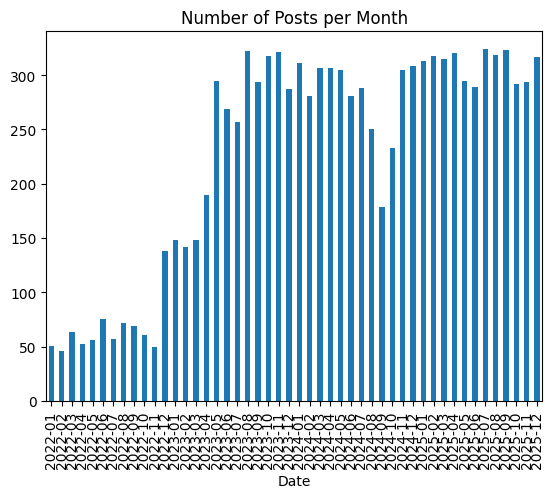

In [6]:
# check amount of data per month
    # convert 'Date' column to datetime
filtered_df['Date'] = pd.to_datetime(filtered_df['Date'], format='mixed')

    # group by month and count the number of posts
monthly_counts = filtered_df.groupby(filtered_df['Date'].dt.to_period('M')).size()

    # plot
monthly_counts.plot(kind='bar', title='Number of Posts per Month')

Emotion distribution:
emotion_label
neutral     0.362037
joy         0.155185
fear        0.149659
surprise    0.144594
anger       0.103518
sadness     0.064376
disgust     0.020630
Name: proportion, dtype: float64


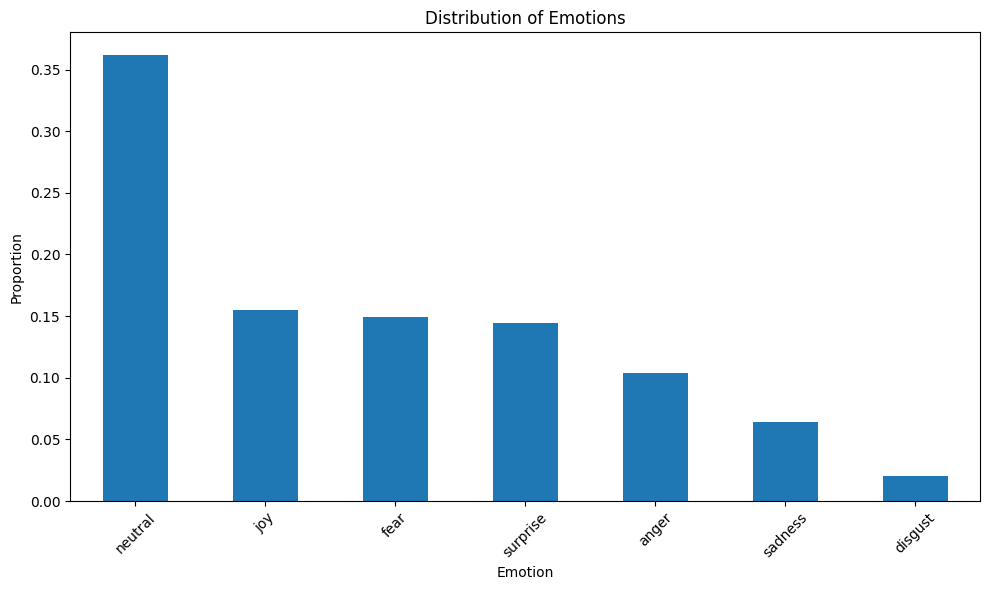

In [7]:
# Plot emotions distribution
emotion_distribution = filtered_df['emotion_label'].value_counts(normalize=True)
print("Emotion distribution:")
print(emotion_distribution)

# Plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
emotion_distribution.plot(kind='bar')
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()